In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from typing import Callable
import networkx as nx

In [3]:
def plot_mapper_graph(vertex_set, edge_set, title="Mapper Graph"):
    vertex_names = [f'v{i}' for i in range(len(vertex_set))]

    vertex_mapping = {frozenset(v): vertex_names[i] for i, v in enumerate(vertex_set)}

    edges_named = []
    for vertex1, vertex2 in edge_set:
        edges_named.append((vertex_mapping[frozenset(vertex1)], vertex_mapping[frozenset(vertex2)]))

    G = nx.Graph()
    G.add_nodes_from(vertex_names)
    G.add_edges_from(edges_named)

    node_sizes = [len(v) * 1 for v in vertex_set]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=node_sizes,
        node_color='skyblue',
        edge_color='gray',
        font_size=12
    )
    plt.title(title)
    plt.show()



def mapper(data: pd.DataFrame, lens: Callable, cover_set: list, clustering_alg: DBSCAN):
    vertex_set = []
    edge_set = []

    lens_values = lens(data)

    for i, Ui in enumerate(cover_set):
        (ax, bx), (ay, by) = Ui
        Xi = data[(lens_values[:, 0] >= ax) & (lens_values[:, 0] <= bx) & (lens_values[:, 1] >= ay) & (lens_values[:, 1] <= by)]

        labels = clustering_alg.fit(Xi).labels_

        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)

        for j, cluster_label in enumerate(sorted(unique_labels)):

            members = Xi.index[labels == cluster_label]
            vertex = set(members)
            vertex_name = f'v{i}{j}'
            vertex_set.append(vertex)


    for i, vertex1 in enumerate(vertex_set):
        for j, vertex2 in enumerate(vertex_set):
            if i < j:
              if vertex1.intersection(vertex2):
                  edge_set.append((vertex1, vertex2))

    return vertex_set, edge_set


In [5]:
df = pd.read_csv('noisy_annuli_bridge.csv')

In [6]:
df.head()

,x,y,label,component
0,-6.617106,1.625012,0,left_annulus
1,-2.509268,-0.798896,0,left_annulus
2,-5.311963,-2.902399,0,left_annulus
3,-7.204998,-1.622039,0,left_annulus
4,-3.461512,2.383244,0,left_annulus


In [7]:
X = df['x']
y = df['y']

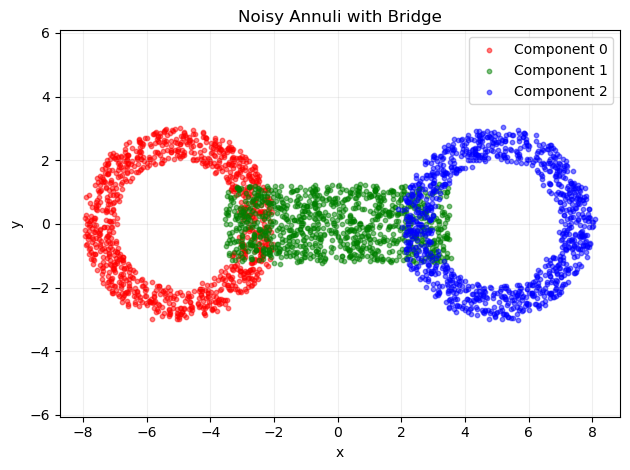

In [8]:
colors = ['red', 'green', 'blue']
for label, color in enumerate(colors):
    mask = df['label'] == label
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               color=color, alpha=0.5, s=10, label=f'Component {label}')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noisy Annuli with Bridge')
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.tight_layout()
plt.show()

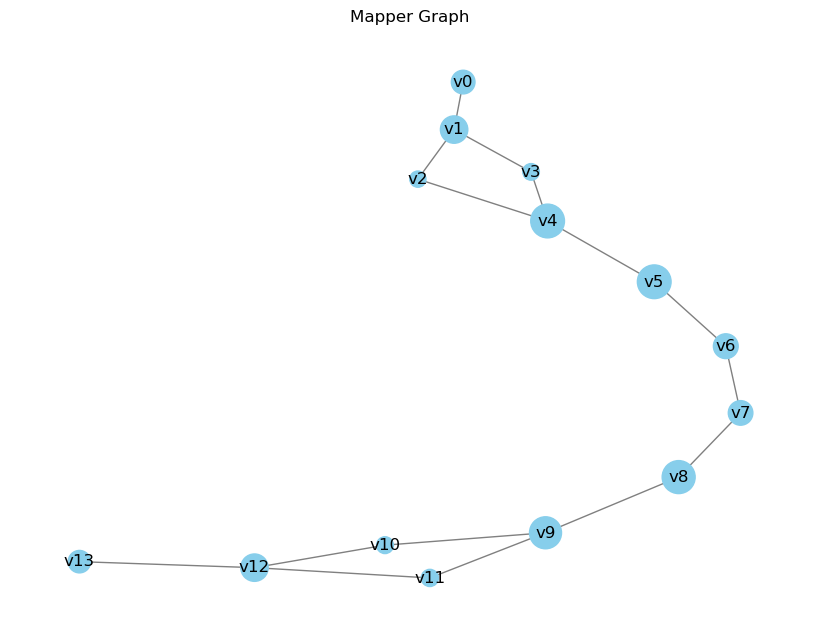

In [9]:
from sklearn.cluster import DBSCAN

def lens(X):
    return X.to_numpy()


def make_horizontal_cover(X, n_intervals=12, overlap=0.3):
    x_min, x_max = X.iloc[:, 0].min(), X.iloc[:, 0].max()
    y_min, y_max = X.iloc[:, 1].min(), X.iloc[:, 1].max()

    padding = 0.5
    x_min -= padding
    x_max += padding
    y_min -= padding
    y_max += padding

    x_step = (x_max - x_min) / n_intervals
    overlap_amount = x_step * overlap

    cover_set = []

    for i in range(n_intervals):
        ax = x_min + i * x_step - (overlap_amount if i > 0 else 0)
        bx = x_min + (i + 1) * x_step + (overlap_amount if i < n_intervals - 1 else 0)

        ay = y_min
        by = y_max

        cover_set.append(((ax, bx), (ay, by)))

    return cover_set

clustering_alg = DBSCAN(eps=0.6, min_samples=5)
data = df[['x', 'y']]

cover_set = make_horizontal_cover(data, n_intervals=12, overlap=0.3)

vertex_set, edge_set = mapper(data, lens, cover_set, clustering_alg)

plot_mapper_graph(vertex_set, edge_set)
